<a href="https://colab.research.google.com/github/Bharani-a123/ML-JOURNEY/blob/main/TitanicDataPReprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/TITANIC_CLEANED.csv")
df.head()

,pclass,survived,sex,age,sibsp,parch,fare,embarked
0,1,1,female,29.00,0,0,211.3375,S
1,1,1,male,0.92,1,2,151.5500,S
2,1,0,female,2.00,1,2,151.5500,S
3,1,0,male,30.00,1,2,151.5500,S
4,1,0,female,25.00,1,2,151.5500,S


In [ ]:
print(df.isnull().sum())
df.info()

pclass      0
survived    0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1037 entries, 0 to 1036
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1037 non-null   int64  
 1   survived  1037 non-null   int64  
 2   sex       1037 non-null   object 
 3   age       1037 non-null   float64
 4   sibsp     1037 non-null   int64  
 5   parch     1037 non-null   int64  
 6   fare      1037 non-null   float64
 7   embarked  1037 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 64.9+ KB


In [ ]:
df.describe()

,pclass,survived,age,sibsp,parch,fare
count,1037.000000,1037.000000,1037.000000,1037.000000,1037.000000,1037.000000
mean,2.213115,0.409836,29.514147,0.504339,0.423337,36.510754
std,0.839368,0.492041,13.920077,0.914929,0.842383,55.602750
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,21.000000,0.000000,0.000000,8.050000
50%,2.000000,0.000000,28.000000,0.000000,0.000000,15.750000
75%,3.000000,1.000000,38.000000,1.000000,1.000000,35.500000
max,3.000000,1.000000,66.000000,8.000000,6.000000,512.329200


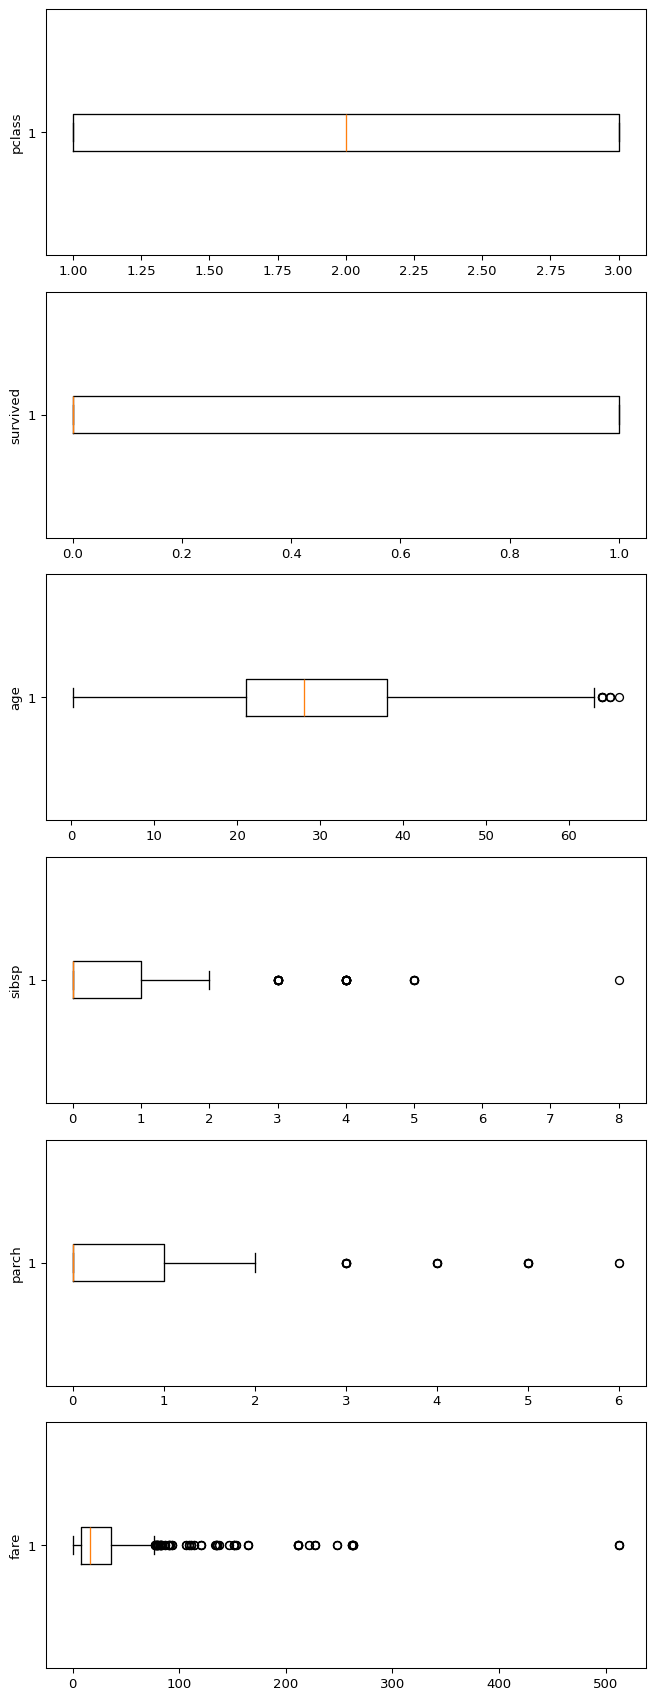

In [ ]:
fig,axe=plt.subplots(len(df.select_dtypes(include=np.number).columns),1,figsize=(7,18),dpi=95)
for i,col in enumerate(df.select_dtypes(include=np.number).columns):
  axe[i].boxplot(df[col],vert=False)
  axe[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [ ]:
num_cols = ['age']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]


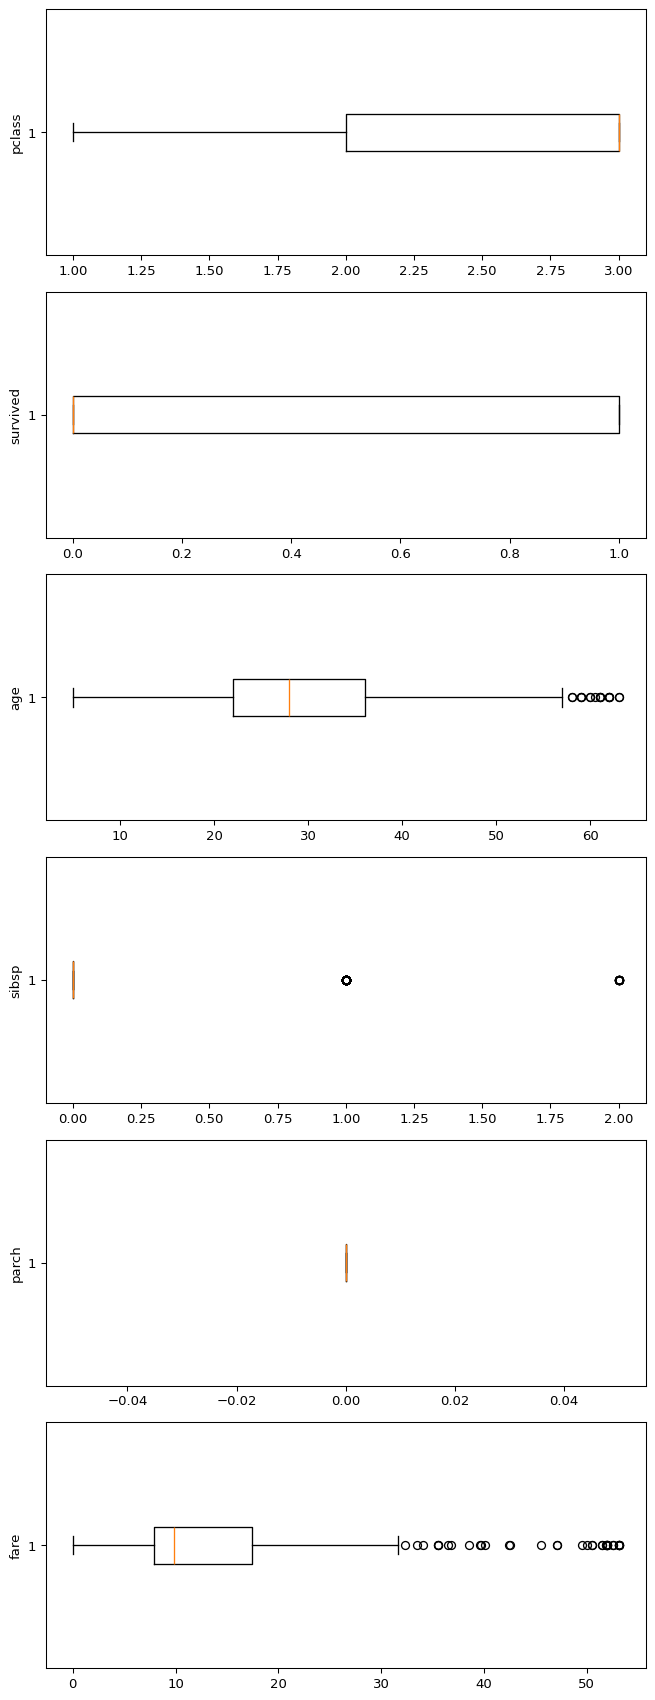

In [ ]:
'''fig,axe=plt.subplots(len(df.select_dtypes(include=np.number).columns),1,figsize=(7,18),dpi=95)
for i,col in enumerate(df.select_dtypes(include=np.number).columns):
  axe[i].boxplot(df[col],vert=False)
  axe[i].set_ylabel(col)
plt.tight_layout()
plt.show()'''


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1028 entries, 0 to 1036
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1028 non-null   int64  
 1   survived  1028 non-null   int64  
 2   sex       1028 non-null   object 
 3   age       1028 non-null   float64
 4   sibsp     1028 non-null   int64  
 5   parch     1028 non-null   int64  
 6   fare      1028 non-null   float64
 7   embarked  1028 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 72.3+ KB


In [ ]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

num_cols = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
corr = df[num_cols].corr()

print(corr['survived'])


survived    1.000000
pclass     -0.329536
sex         0.533321
age        -0.042303
sibsp      -0.015018
parch       0.115054
fare        0.258592
Name: survived, dtype: float64


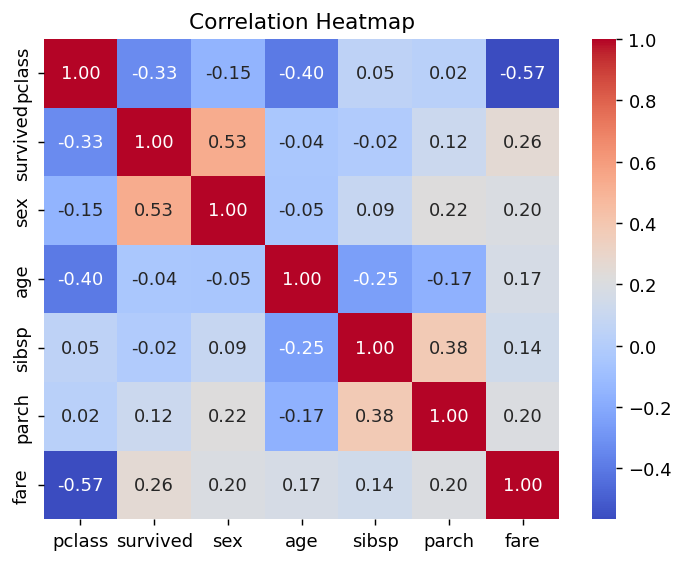

survived    1.000000
sex         0.533321
fare        0.258592
parch       0.115054
sibsp      -0.015018
age        -0.042303
pclass     -0.329536
Name: survived, dtype: float64


In [44]:
# Calculate correlation only for numeric columns
corr = df.corr(numeric_only=True)

plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Print correlation of all features with target 'survived'
print(corr['survived'].sort_values(ascending=False))


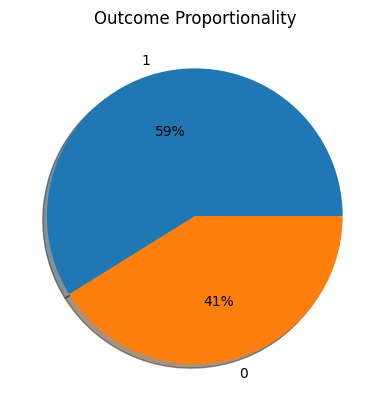

In [46]:
plt.pie(df['survived'].value_counts(), labels=[
        1,0], autopct='%.f%%', shadow=True)
plt.title('Outcome Proportionality')
plt.show()